# Final Project: [ชื่อโครงงาน]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: ชื่อ-นามสกุล (รหัส)
- สมาชิกที่ 2: ชื่อ-นามสกุล (รหัส)
- สมาชิกที่ 3: ชื่อ-นามสกุล (รหัส) *(ถ้ามี)*

**Dataset:** Heart Disease Dataset (Hungarian Institute of Cardiology, UCI Machine Learning Repository), `data.csv`

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ⬜ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [ ]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [9]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('data.csv')

# แสดงข้อมูลพื้นฐาน
# ─── โหลด Dataset และ Data Cleaning เบื้องต้น ──────────────────────
# ตัดช่องว่างในชื่อคอลัมน์ และแปลงเครื่องหมาย '?' เป็น NaN
df_raw = pd.read_csv('data.csv')
df_raw.columns = df_raw.columns.str.strip()

print(f'Shape ของชุดข้อมูลตั้งต้น: {df_raw.shape}')
print(f'รายชื่อคอลัมน์: {df_raw.columns.tolist()}')

# ตรวจสอบค่า '?' (missing values)
df_clean = df_raw.replace('?', np.nan)
print(f'\nจำนวน Missing values ก่อนจัดการ:\n{df_clean.isnull().sum()}')

# คอลัมน์ slope (190), ca (291), thal (266) มีค่าสูญหายมากเกินไป จึงตัดออก
# และแปลงคอลัมน์ที่เหลือเป็นตัวเลข พร้อมเติมค่าสูญหายด้วย Median
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
target_col = 'num'

df = df_clean[feature_cols + [target_col]].copy()
for col in df.columns:
    df[col] = pd.to_numeric(df[col])

df = df.fillna(df.median())
print(f'\nShape หลัง Clean: {df.shape}')
df.head()

Shape ของชุดข้อมูลตั้งต้น: (294, 14)
รายชื่อคอลัมน์: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

จำนวน Missing values ก่อนจัดการ:
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

Shape หลัง Clean: (294, 11)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0


=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
age,294.0,47.826531,7.811812,28.0,42.00,49.0,54.0,66.0
sex,294.0,0.724490,0.447533,0.0,0.00,1.0,1.0,1.0
cp,294.0,2.982993,0.965117,1.0,2.00,3.0,4.0,4.0
trestbps,294.0,132.574830,17.597108,92.0,120.00,130.0,140.0,200.0
chol,294.0,250.234694,64.982245,85.0,211.25,243.0,277.0,603.0
fbs,294.0,0.068027,0.252222,0.0,0.00,0.0,0.0,1.0
restecg,294.0,0.217687,0.460257,0.0,0.00,0.0,0.0,2.0
thalach,294.0,139.132653,23.549514,82.0,122.00,140.0,155.0,190.0
exang,294.0,0.302721,0.460219,0.0,0.00,0.0,1.0,1.0
oldpeak,294.0,0.586054,0.908648,0.0,0.00,0.0,1.0,5.0


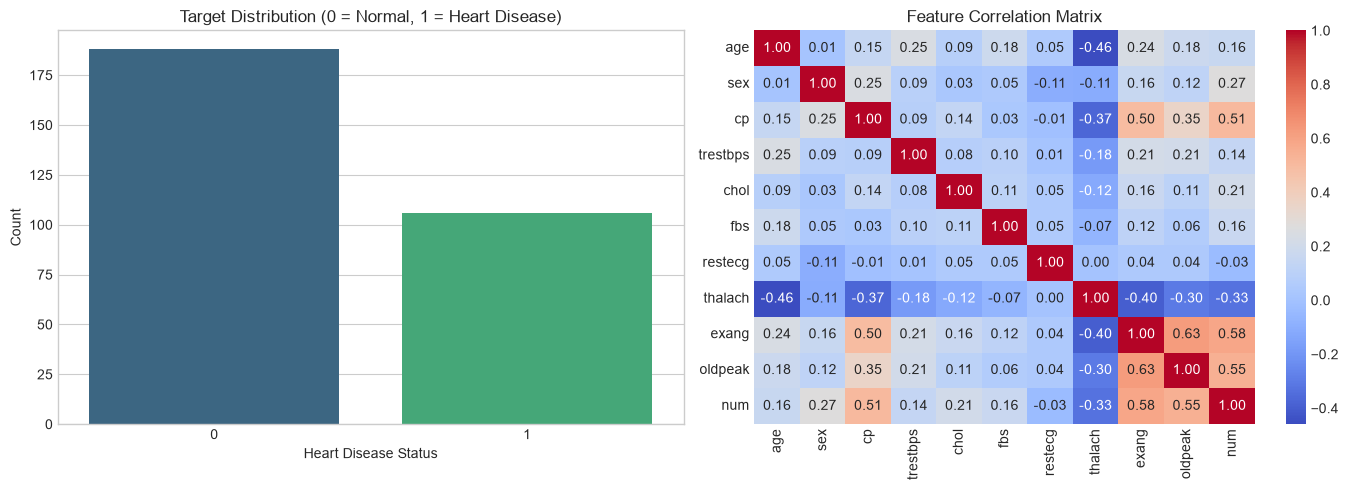

In [13]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
# 1. Summary Statistics
print("=== Descriptive Statistics ===")
display(df.describe().T)

# 2. Distribution Plot ของ Target
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=target_col, data=df, hue=target_col, palette='viridis', legend=False, ax=ax[0])
ax[0].set_title('Target Distribution (0 = Normal, 1 = Heart Disease)')
ax[0].set_xlabel('Heart Disease Status')
ax[0].set_ylabel('Count')

# 3. Correlation Heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

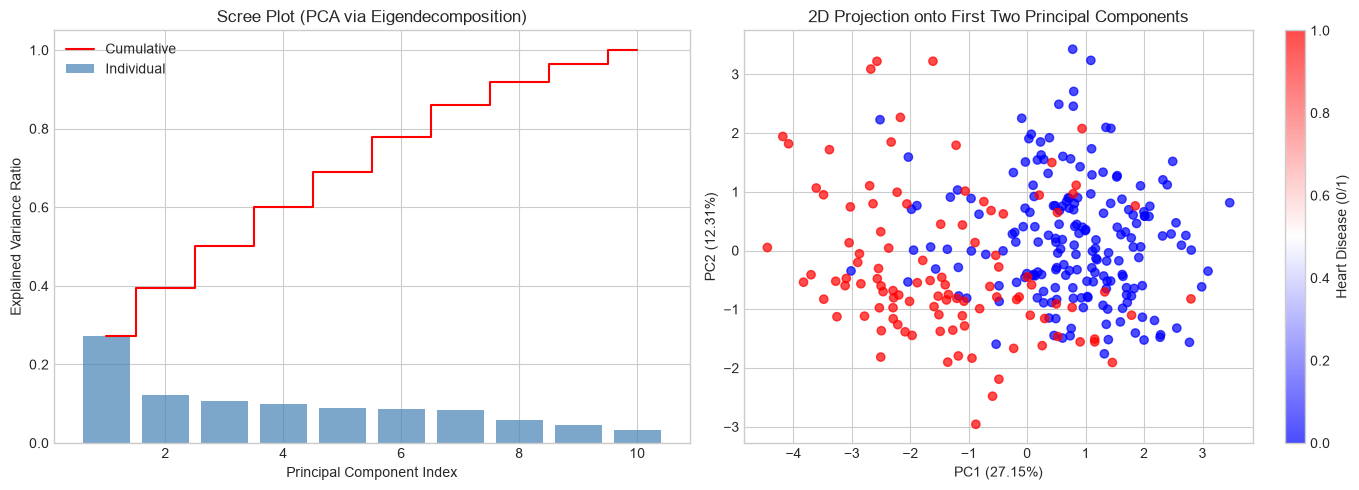

Top 3 Feature Contributions for PC1:
- exang: 0.4875
- oldpeak: 0.4259
- thalach: 0.4174


In [12]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: [ระบุว่าทำอะไร — PCA / SVD / Covariance]

# TODO: เขียน code ที่นี่
X_features = df[feature_cols].values
X_std = (X_features - X_features.mean(axis=0)) / X_features.std(axis=0)

# 2. คำนวณ Covariance Matrix (1/(n-1) * X.T @ X)
n = X_std.shape[0]
cov_matrix = (1 / (n - 1)) * (X_std.T @ X_std)

# 3. Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# เรียงลำดับจากค่า Eigenvalue มากไปน้อย
idx_sorted = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx_sorted]
eigenvectors = eigenvectors[:, idx_sorted]

# คำนวณ Explained Variance Ratio
var_explained = eigenvalues / np.sum(eigenvalues)
cum_var_explained = np.cumsum(var_explained)

# 4. แสดง Scree Plot และ Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(var_explained) + 1), var_explained, alpha=0.7, color='steelblue', label='Individual')
axes[0].step(range(1, len(cum_var_explained) + 1), cum_var_explained, where='mid', color='red', label='Cumulative')
axes[0].set_xlabel('Principal Component Index')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (PCA via Eigendecomposition)')
axes[0].legend()

# 5. Project ข้อมูลลงสู่ 2D Space (PC1 vs PC2)
pc1_pc2 = X_std @ eigenvectors[:, :2]
scatter = axes[1].scatter(pc1_pc2[:, 0], pc1_pc2[:, 1], c=df['num'], cmap='bwr', alpha=0.7)
axes[1].set_xlabel(f'PC1 ({var_explained[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({var_explained[1]*100:.2f}%)')
axes[1].set_title('2D Projection onto First Two Principal Components')
plt.colorbar(scatter, ax=axes[1], label='Heart Disease (0/1)')

plt.tight_layout()
plt.show()

print(f"Top 3 Feature Contributions for PC1:\n" + 
      "\n".join([f"- {feature_cols[i]}: {abs(eigenvectors[i, 0]):.4f}" 
                 for i in np.argsort(np.abs(eigenvectors[:, 0]))[::-1][:3]]))

**Insight จาก CLO1 Analysis:**
> [อธิบายสิ่งที่ค้นพบ — เช่น PC1 อธิบาย X% variance, features ไหน contribute มากที่สุด]

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

In [5]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)
pass

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

In [6]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
# model1 = ???
# model1.fit(X_train, y_train)
# ...
pass

In [7]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

# TODO:
# model2 = ???
# ...
pass

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: ___ | | | |
| Model 2: ___ | | | |

**Insight:**
> [เปรียบเทียบ: Model ไหนดีกว่า? ทำไม? มี overfitting/underfitting ไหม?]

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [8]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# models = {
#     'Model 1': ???,
#     'Model 2': ???,
#     'Model 3': ???,
# }
#
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
#     cv_mse = -scores.mean()
#     print(f'{name}: CV MSE = {cv_mse:.4f}')
pass

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: ...
- CLO2: ...
- CLO3: ...
- CLO4: ...

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]

**6.4 Connection กับ Topics ในวิชา:**
> [เชื่อมกับ Week ต่างๆ ที่เรียนมา ว่า concept ไหนนำมาใช้จริงในโครงงานนี้]

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]